In [1]:
import pandas as pd 
data = pd.read_csv("/home/ego4d/data/v2/video_540ss_splits/test_ego4d.csv")
data.head(1)

,path,num_frames,fps,duration_sec,source
0,/home/ego4d/data/v2/video_540ss_splits/6fd90f8...,5376,30.0,179.2,ego4d


In [2]:
data.iloc[0]['path']

'/home/ego4d/data/v2/video_540ss_splits/6fd90f8d-7a4d-425d-a812-3268db0b0342/6fd90f8d-7a4d-425d-a812-3268db0b0342_0012.mp4'

In [3]:
from models.rvm_tf import RecurrentWorldModel
import torch
import yaml
import numpy as np
import cv2
import matplotlib.pyplot as plt
import torch.nn.functional as F
from icecream import ic

In [4]:
with open("/home/rvm/configs/train_ema.yaml", "r") as f:
    config = yaml.safe_load(f)
model = RecurrentWorldModel(**config.get("model", {}))

/root/miniconda3/envs/gssl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


loading the vision encoder from facebook/dinov2-with-registers-small


Loading weights: 100%|██████████| 224/224 [00:00<00:00, 7252.32it/s]


In [5]:
checkpoint = torch.load("/home/rvm/checkpoints/checkpoints_rwm/exp_1787891923.9649274/model_epoch3_step5400.pth", weights_only=False)
model.load_state_dict(checkpoint['model'])

<All keys matched successfully>

In [46]:
# video_path = '/home/ego4d/data/v2/video_540ss/aef6d4d8-7a78-4744-a8a2-dba4edeb1997.mp4'
video_path = data.iloc[80]['path']


cap = cv2.VideoCapture(video_path)
if not cap.isOpened():
    print("Cannot open video")

fps = cap.get(cv2.CAP_PROP_FPS)  # native fps, needed to convert frame idx -> seconds

frames = []
while True:
    ret, frame = cap.read()
    if not ret: break
    frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    frame = cv2.resize(frame, (252, 252))
    frame = frame / 255.0
    frames.append(frame)

print(len(frames))
stride = 20
frames = frames[::stride]
print(len(frames))

# raw frame indices these strided samples correspond to in the original video
all_indices = np.arange(0, len(frames) * stride, stride)

5376
269


In [47]:
device = "cuda"
model = model.to(device)
model.eval()

Base = 4       # starting position in (strided) frames
C = 15           # number of context frames
S = 5            # number of future frames to predict

context_frames = np.stack(frames[Base : Base + C])
context = torch.tensor(context_frames, dtype=torch.float32)                 # (C, H, W, 3)
context = context.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, C, 3, H, W)

target_frames = np.stack(frames[Base + C : Base + C + S])
targets = torch.tensor(target_frames, dtype=torch.float32)                  # (S, H, W, 3)
targets = targets.permute(0, 3, 1, 2).unsqueeze(0).to(device)               # (1, S, 3, H, W)

# sampled_indices: raw frame indices for this window (matches dataset's sampled_indices)
sampled_indices = all_indices[Base : Base + C + S]
context_indices = sampled_indices[:C]
target_indices = sampled_indices[C:C + S]

# frame_times: seconds, computed as sampled_indices / fps (RoPE time axis)
context_times = torch.tensor(context_indices / fps, dtype=torch.float32).unsqueeze(0).to(device)   # (1, C)
target_times = torch.tensor(target_indices / fps, dtype=torch.float32).unsqueeze(0).to(device)      # (1, S)

with torch.no_grad():
    out_tf = model.teacher_forcing_rollout_repr(
        context=context,
        targets=targets,
        context_times=context_times,
        target_times=target_times,
    )

preds_tf = out_tf["pred"]
target_feat_tf = out_tf["target_feat"]
context_memory_tf = out_tf["context_memory"]
context_feat_tf = out_tf["context_feat"]

print("context:", context.shape)
print("targets:", targets.shape)
print("context_times:", context_times)
print("target_times:", target_times)
print("preds_tf:", preds_tf.shape)


context: torch.Size([1, 15, 3, 252, 252])
targets: torch.Size([1, 5, 3, 252, 252])
context_times: tensor([[ 2.6667,  3.3333,  4.0000,  4.6667,  5.3333,  6.0000,  6.6667,  7.3333,
          8.0000,  8.6667,  9.3333, 10.0000, 10.6667, 11.3333, 12.0000]],
       device='cuda:0')
target_times: tensor([[12.6667, 13.3333, 14.0000, 14.6667, 15.3333]], device='cuda:0')
preds_tf: torch.Size([1, 5, 325, 384])


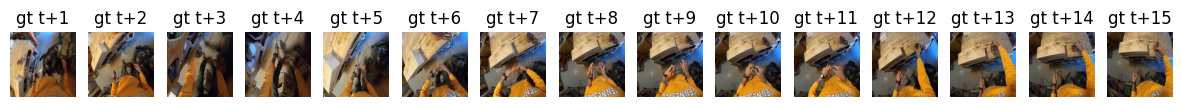

In [49]:
gt = context_frames
fig, axes = plt.subplots(1, C, figsize=(3 * S, 6))
for s in range(C):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


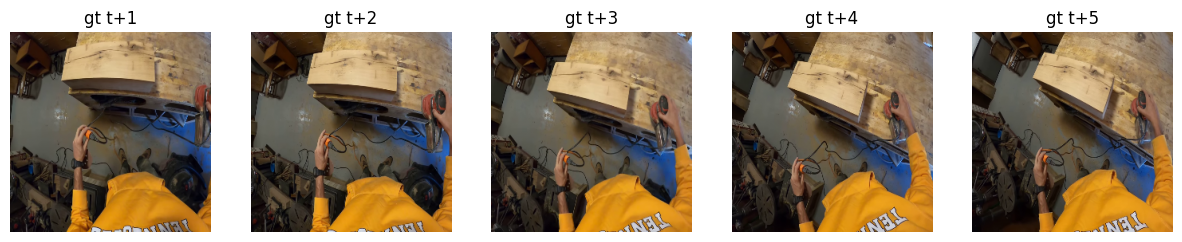

In [50]:
gt = target_frames
fig, axes = plt.subplots(1, S, figsize=(3 * S, 6))
for s in range(S):
    axes[s].imshow(gt[s])
    axes[s].set_title(f"gt t+{s+1}")
    axes[s].axis("off")


frame 0: explained variance = [0.21  0.152 0.078]  (sum 0.440)
frame 1: explained variance = [0.231 0.148 0.072]  (sum 0.451)
frame 2: explained variance = [0.25  0.132 0.071]  (sum 0.453)
frame 3: explained variance = [0.244 0.14  0.076]  (sum 0.460)
frame 4: explained variance = [0.242 0.152 0.071]  (sum 0.466)


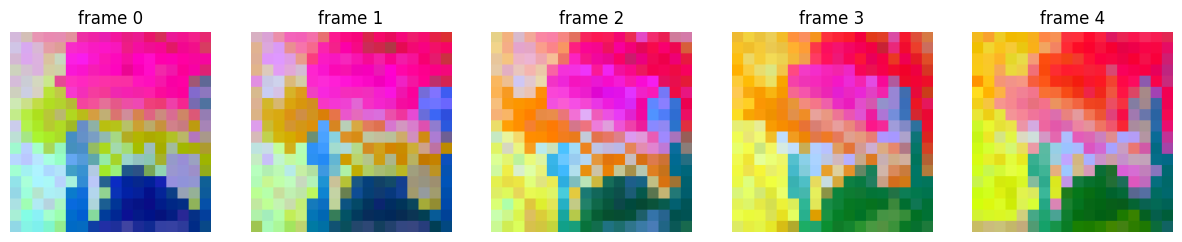

In [51]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(target_feat_tf[:, :, 1:, :])
feats_pca_image = show(pca_feats)

frame 0: explained variance = [0.43  0.179 0.083]  (sum 0.692)
frame 1: explained variance = [0.403 0.21  0.092]  (sum 0.705)
frame 2: explained variance = [0.371 0.224 0.097]  (sum 0.692)
frame 3: explained variance = [0.379 0.22  0.09 ]  (sum 0.690)
frame 4: explained variance = [0.388 0.212 0.087]  (sum 0.686)


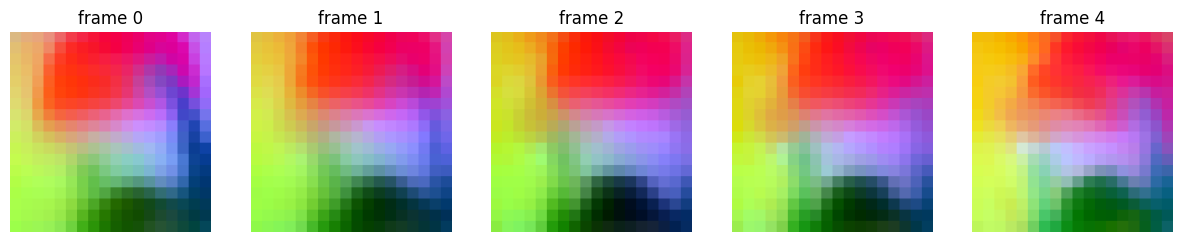

In [52]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(preds_tf[:, :, 1:, :])
feats_pca_image = show(pca_feats)

In [ ]:


def frame_knn(ground_truth_feat, predicted_feat, indices, topk=(1, 3, 5), context_len=None):
    bs, T_gt, num_p, dim = ground_truth_feat.shape
    T_pred = predicted_feat.shape[1]
    device = predicted_feat.device

    gt = F.normalize(ground_truth_feat[:, :, 1:], dim=-1)
    pred = F.normalize(predicted_feat[:, :, 1:], dim=-1)
    sim = torch.einsum("btpd,bspd->bts", pred, gt) / gt.shape[2]

    order = sim.argsort(dim=-1, descending=True)
    idx = torch.as_tensor(indices, device=device).view(1, T_pred, 1)
    rank = (order == idx).float().argmax(dim=-1)

    gt_sim = sim.gather(-1, idx.expand(bs, T_pred, 1)).squeeze(-1)
    best_sim = sim.gather(-1, order[..., :1]).squeeze(-1)

    out = {f"top{k}": (rank < k).float().mean().item() for k in topk}
    out["mean_rank"] = rank.float().mean().item()
    out["per_step_rank"] = rank.float().mean(0).tolist()
    out["chance_top1"] = 1.0 / T_gt

    out["sim"] = sim                                  # (B, T_pred, T_gt) full matrix
    out["retrieved"] = order[..., 0]                  # (B, T_pred) best-matching gt index
    out["target"] = idx.expand(bs, T_pred, 1).squeeze(-1)
    out["retrieved_sim"] = best_sim                   # score of the retrieved frame
    out["target_sim"] = gt_sim                        # score of the frame it should have been
    out["rank"] = rank                                # (B, T_pred) per-sample rank
    out["order"] = order                              # (B, T_pred, T_gt) full ranking

    if context_len is not None:
        last = context_len - 1
        out["copy_rate"] = (order[..., 0] == last).float().mean().item()
        out["copy_sim"] = sim[..., last]
        out["copy_beats_gt"] = (sim[..., last] > gt_sim).float().mean().item()

    return out

In [54]:
representations = torch.cat((context_feat_tf, target_feat_tf), dim=1)

C = context_feat_tf.shape[1]
S = target_feat_tf.shape[1]
indices = list(range(C, C + S))
print(C, S)

# frame_knn(representations, preds_tf, indices, context_len=C)

r = frame_knn(representations, preds_tf, indices, context_len=C)
for s in range(len(indices)):
    print(f"s={s}  want {r['target'][0,s].item():2d} (sim {r['target_sim'][0,s]:.4f})   "
          f"got {r['retrieved'][0,s].item():2d} (sim {r['retrieved_sim'][0,s]:.4f})   "
          f"copy {r['copy_sim'][0,s]:.4f}   rank {int(r['rank'][0,s])}")

15 5
s=0  want 15 (sim 0.6928)   got 13 (sim 0.8709)   copy 0.8412   rank 10
s=1  want 16 (sim 0.7952)   got 14 (sim 0.8293)   copy 0.8293   rank 2
s=2  want 17 (sim 0.7412)   got 15 (sim 0.8711)   copy 0.7556   rank 3
s=3  want 18 (sim 0.7491)   got 16 (sim 0.8793)   copy 0.7536   rank 4
s=4  want 19 (sim 0.7953)   got 17 (sim 0.8653)   copy 0.7519   rank 3


frame 0: explained variance = [0.214 0.123 0.088]  (sum 0.425)
frame 1: explained variance = [0.213 0.124 0.081]  (sum 0.418)
frame 2: explained variance = [0.167 0.129 0.081]  (sum 0.377)
frame 3: explained variance = [0.159 0.127 0.084]  (sum 0.369)
frame 4: explained variance = [0.16  0.131 0.094]  (sum 0.385)
frame 5: explained variance = [0.149 0.14  0.096]  (sum 0.385)
frame 6: explained variance = [0.16  0.137 0.085]  (sum 0.382)


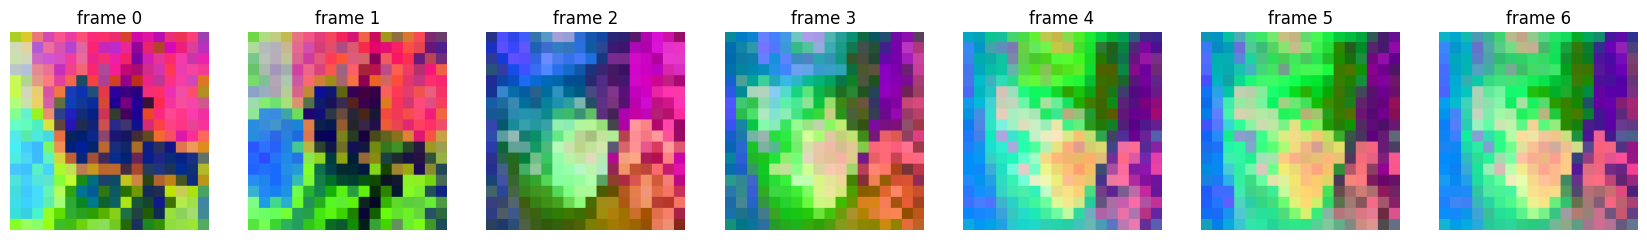

In [15]:
pca_feats = pca_per_frame(context_memory_tf[:, C-7:C, 1:, :])
feats_pca_image = show(pca_feats)


frame 0: explained variance = [0.229 0.138 0.08 ]  (sum 0.447)
frame 1: explained variance = [0.234 0.126 0.084]  (sum 0.444)
frame 2: explained variance = [0.189 0.141 0.087]  (sum 0.417)
frame 3: explained variance = [0.167 0.149 0.088]  (sum 0.403)
frame 4: explained variance = [0.165 0.15  0.107]  (sum 0.422)
frame 5: explained variance = [0.171 0.146 0.111]  (sum 0.427)
frame 6: explained variance = [0.169 0.157 0.1  ]  (sum 0.426)


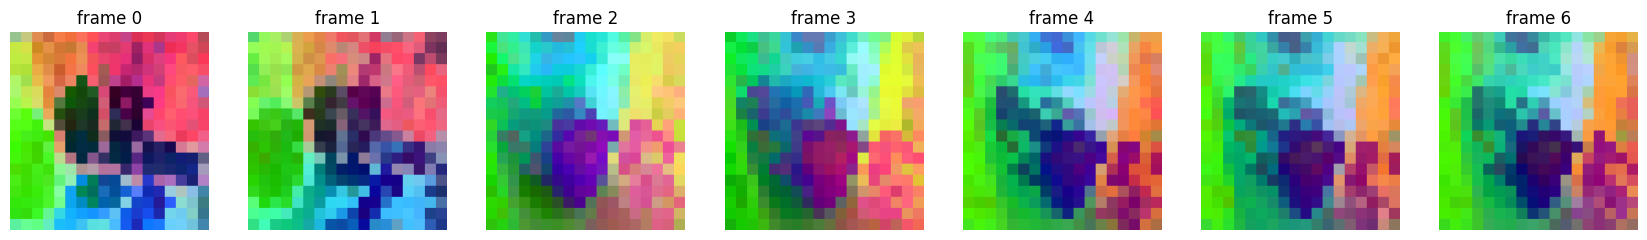

In [16]:
pca_feats = pca_per_frame(context_feat_tf[:, C-7:C, 1:, :])
feats_pca_image = show(pca_feats)

frame 0: explained variance = [0.16  0.131 0.094]  (sum 0.385)
frame 1: explained variance = [0.149 0.14  0.096]  (sum 0.385)
frame 2: explained variance = [0.16  0.137 0.085]  (sum 0.382)
frame 0: explained variance = [0.165 0.15  0.107]  (sum 0.422)
frame 1: explained variance = [0.171 0.146 0.111]  (sum 0.427)
frame 2: explained variance = [0.169 0.157 0.1  ]  (sum 0.426)


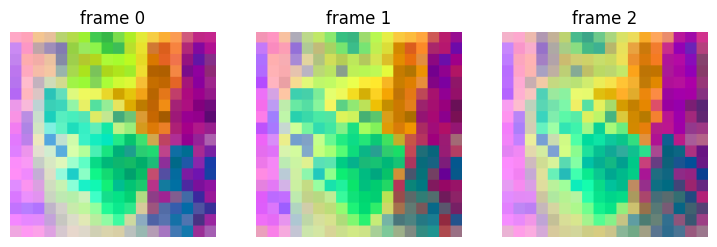

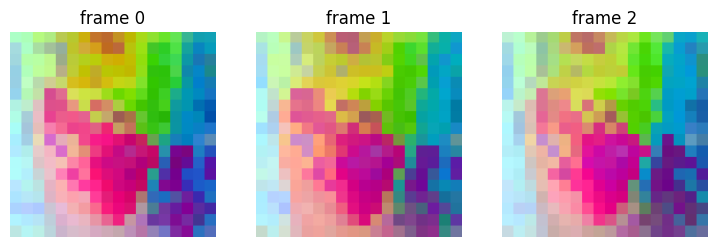

In [17]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_feats = pca_per_frame(context_memory_tf[:, C-3:C, 1:, :])
feats_pca_image = show(pca_feats)

pca_memory = pca_per_frame(context_feat_tf[:, C-3:C, 1:, :])
memory_pca_image = show(pca_memory)

frame 0: explained variance = [0.279 0.147 0.094]  (sum 0.520)
frame 1: explained variance = [0.286 0.116 0.1  ]  (sum 0.502)
frame 2: explained variance = [0.22  0.131 0.105]  (sum 0.457)
frame 3: explained variance = [0.204 0.139 0.089]  (sum 0.432)
frame 4: explained variance = [0.232 0.13  0.076]  (sum 0.437)
frame 5: explained variance = [0.229 0.14  0.071]  (sum 0.439)
frame 6: explained variance = [0.227 0.145 0.071]  (sum 0.443)
frame 7: explained variance = [0.224 0.157 0.076]  (sum 0.456)
frame 8: explained variance = [0.229 0.138 0.08 ]  (sum 0.447)
frame 9: explained variance = [0.234 0.126 0.084]  (sum 0.444)
frame 10: explained variance = [0.189 0.141 0.087]  (sum 0.417)
frame 11: explained variance = [0.167 0.149 0.088]  (sum 0.403)
frame 12: explained variance = [0.165 0.15  0.107]  (sum 0.422)
frame 13: explained variance = [0.171 0.146 0.111]  (sum 0.427)
frame 14: explained variance = [0.169 0.157 0.1  ]  (sum 0.426)


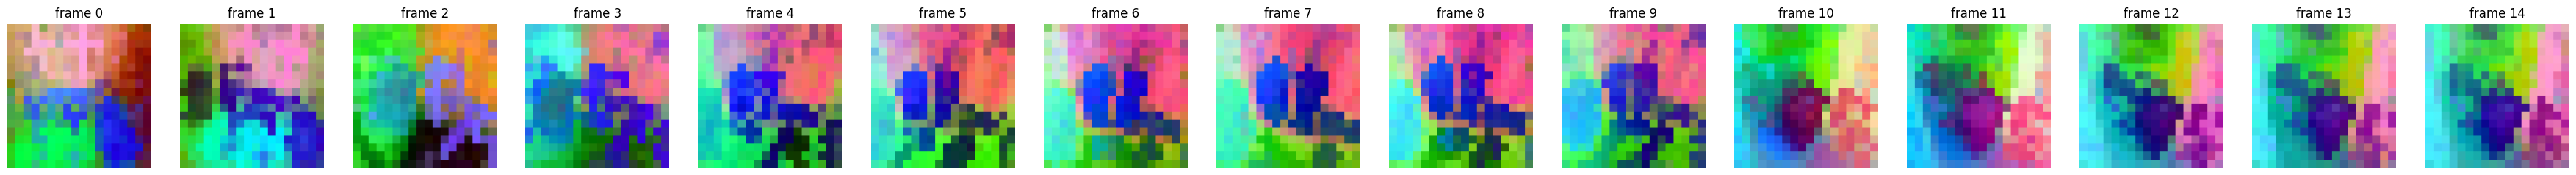

In [18]:
from pca_vis import pca_per_frame, show
# preds.shape
pca_memory = pca_per_frame(context_feat_tf[:, :C, 1:, :])
memory_pca_image = show(pca_memory)